In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, auc

In [7]:
churn_df = pd.read_csv("churn-bigml-80.csv")
churn_df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


/tmp/ipykernel_312656/640672207.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = churn_df.select_dtypes(include=['object', 'bool']).columns.tolist()


--- Model Evaluation ---
Accuracy:  0.8464
Precision: 0.4615
Recall:    0.2278

--- Top Features by Odds Ratio ---


,Feature,Coefficient,Odds_Ratio
66,International plan_Yes,2.286485,9.840291
58,State_TX,1.256461,3.512966
41,State_MT,0.958862,2.608725
55,State_SC,0.872841,2.393702
40,State_MS,0.805056,2.236822


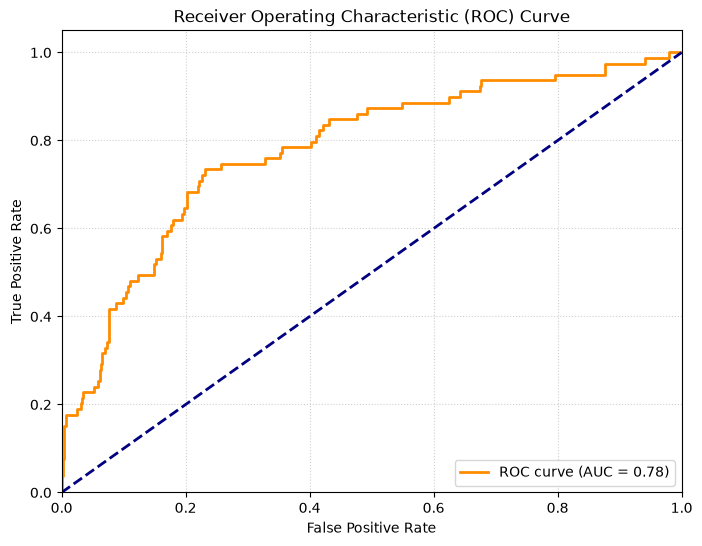

In [8]:

categorical_cols = churn_df.select_dtypes(include=['object', 'bool']).columns.tolist()
le = LabelEncoder()
churn_df['Churn'] = le.fit_transform(churn_df['Churn'])
if 'Churn' in categorical_cols:
    categorical_cols.remove('Churn')


churn_df_encoded = pd.get_dummies(churn_df, columns=categorical_cols, drop_first=True)


X_churn = churn_df_encoded.drop('Churn', axis=1)
y_churn = churn_df_encoded['Churn']


X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_churn, y_churn, test_size=0.2, random_state=42)


numeric_cols = X_train_c.select_dtypes(include=['int64', 'float64']).columns.tolist()
scaler_c = StandardScaler()
X_train_c[numeric_cols] = scaler_c.fit_transform(X_train_c[numeric_cols])
X_test_c[numeric_cols] = scaler_c.transform(X_test_c[numeric_cols])


log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_c, y_train_c)

# 4. Evaluate the Model
y_pred_c = log_model.predict(X_test_c)
y_prob_c = log_model.predict_proba(X_test_c)[:, 1] 

print("--- Model Evaluation ---")
print(f"Accuracy:  {accuracy_score(y_test_c, y_pred_c):.4f}")
print(f"Precision: {precision_score(y_test_c, y_pred_c):.4f}")
print(f"Recall:    {recall_score(y_test_c, y_pred_c):.4f}")


print("\n--- Top Features by Odds Ratio ---")
coef_df = pd.DataFrame({'Feature': X_churn.columns, 'Coefficient': log_model.coef_[0]})

coef_df['Odds_Ratio'] = np.exp(coef_df['Coefficient'])

coef_df = coef_df.sort_values(by='Odds_Ratio', ascending=False)
display(coef_df.head())


fpr, tpr, thresholds = roc_curve(y_test_c, y_prob_c)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()